Titanic Survival Prediction using Machine Learning
**Objective:**
To analyze the Titanic dataset and build machine learning models to predict whether a passenger survived or not.

In [2]:

import pandas as pd

df = pd.read_csv('/content/titanic.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [5]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [6]:
df = df.drop('Cabin', axis=1)

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [9]:
df['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


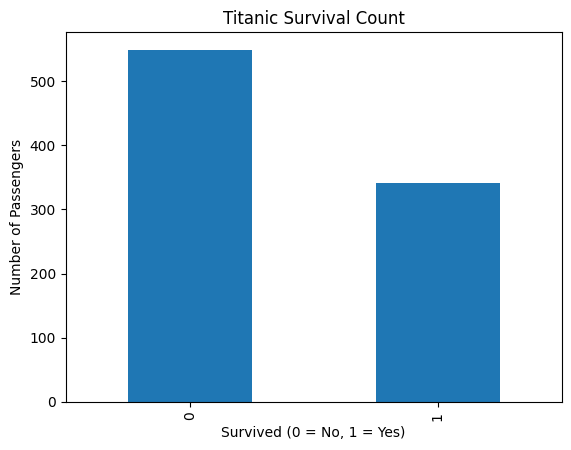

In [10]:
import matplotlib.pyplot as plt

df['Survived'].value_counts().plot(kind='bar')

plt.title('Titanic Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

In [11]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [12]:
df.groupby('Sex')['Survived'].mean() * 100

,Survived
Sex,
female,74.203822
male,18.890815


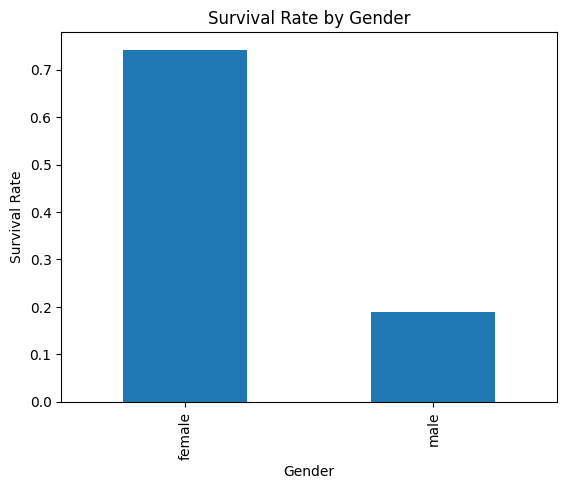

In [13]:
df.groupby('Sex')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

In [14]:
df['Pclass'].value_counts().sort_index()

,count
Pclass,
1,216
2,184
3,491


In [15]:
df.groupby('Pclass')['Survived'].mean() * 100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


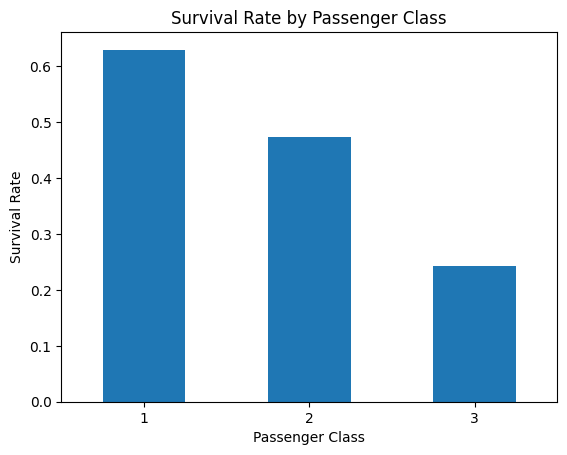

In [16]:
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

In [17]:
df['Age'].describe()

,Age
count,891.000000
mean,29.361582
std,13.019697
min,0.420000
25%,22.000000
50%,28.000000
75%,35.000000
max,80.000000


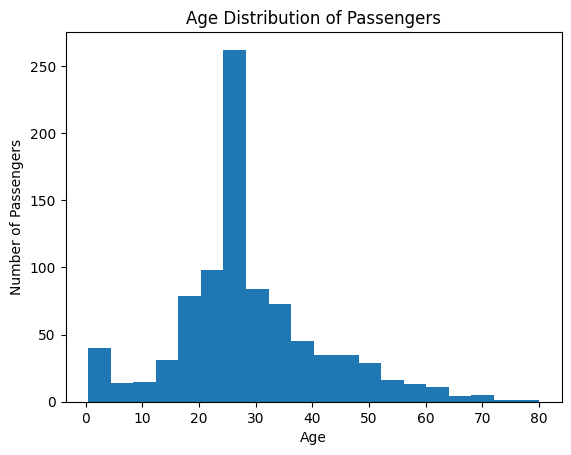

In [18]:
df['Age'].plot(kind='hist', bins=20)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

In [19]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
)

df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100

,Survived
AgeGroup,
Child,57.971014
Teenager,42.857143
Young Adult,35.327103
Adult,40.000000
Senior,22.727273


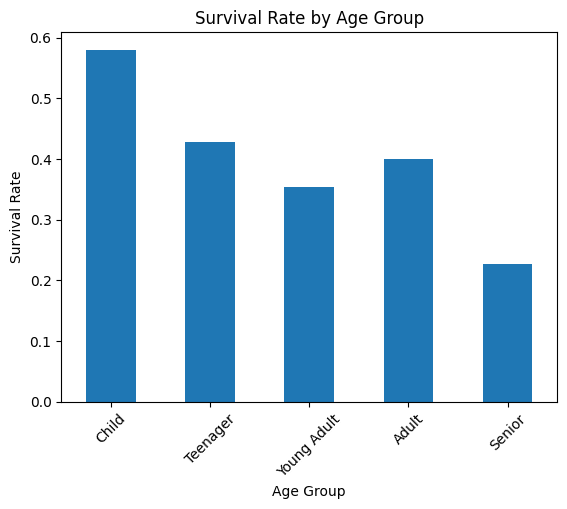

In [20]:
df.groupby('AgeGroup', observed=True)['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.show()

In [21]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean() * 100

Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64

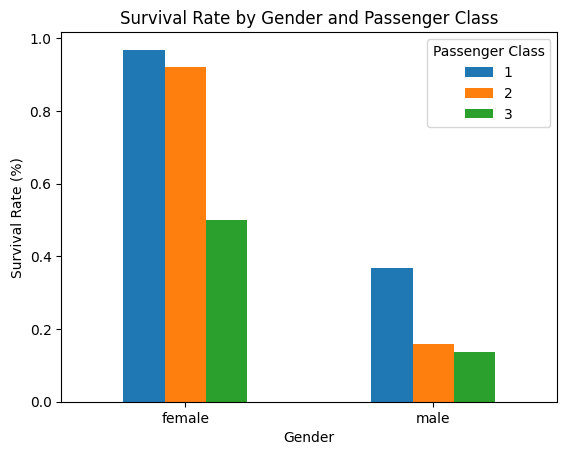

In [22]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack().plot(kind='bar')

plt.title('Survival Rate by Gender and Passenger Class')
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Passenger Class')
plt.show()

In [23]:
pd.crosstab(
    df['Pclass'],
    df['Sex'],
    values=df['Survived'],
    aggfunc='mean'
) * 100

Sex,female,male
Pclass,,
1,96.808511,36.885246
2,92.105263,15.740741
3,50.000000,13.544669


In [24]:
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]
y = df['Survived']

In [25]:
X = pd.get_dummies(X, columns=['Sex'], drop_first=True)

In [26]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male
0,3,22.0,1,0,7.2500,True
1,1,38.0,1,0,71.2833,False
2,3,26.0,0,0,7.9250,False
3,1,35.0,1,0,53.1000,False
4,3,35.0,0,0,8.0500,True


In [27]:
X.shape, y.shape

((891, 6), (891,))

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 6)
Testing data: (179, 6)


In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)


In [33]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [34]:
LogisticRegression(...)


LogisticRegression(penalty=Ellipsis)

In [35]:
y_pred = model.predict(X_test)


In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


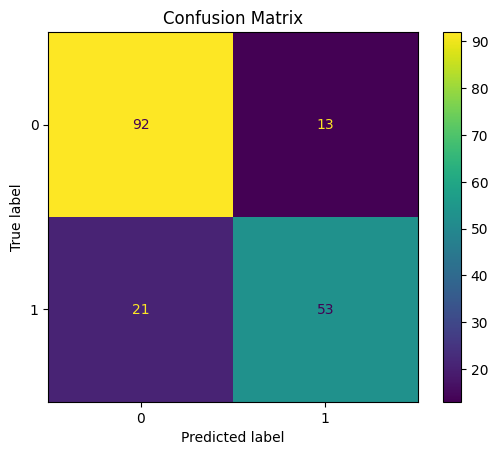

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title('Confusion Matrix')
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [39]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.8100558659217877


In [42]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)


In [43]:
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [44]:
dt_pred = dt_model.predict(X_test)


In [45]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8044692737430168


In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


In [47]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [48]:
rf_pred = rf_model.predict(X_test)

In [49]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8100558659217877


In [50]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.810056
1,Decision Tree,0.804469
2,Random Forest,0.810056


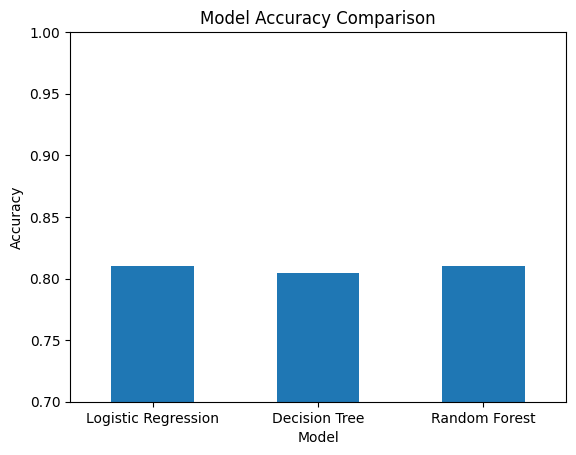

In [51]:
results.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend=False
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.show()

In [52]:
best_model = results.loc[results['Accuracy'].idxmax()]

print("Best Model:", best_model['Model'])
print("Best Accuracy:", best_model['Accuracy'])

Best Model: Logistic Regression
Best Accuracy: 0.8100558659217877


In [53]:
print(results)

                 Model  Accuracy
0  Logistic Regression  0.810056
1        Decision Tree  0.804469
2        Random Forest  0.810056


In [54]:
print("Best Model:", best_model['Model'])
print("Best Accuracy:", best_model['Accuracy'])

Best Model: Logistic Regression
Best Accuracy: 0.8100558659217877


In [56]:
final_predictions = rf_model.predict(X_test)

print(final_predictions[:10])

[0 0 0 1 0 1 1 0 1 1]
